# Car Price Prediction Using Machine Learning

Predicting Used Car Selling Prices Using Regression Models

## Problem Statement

Used car prices depend on several factors such as the car's brand, age, mileage, fuel type, transmission, and other characteristics.

The objective of this project is to develop a machine learning regression system that can learn the relationship between these features and the selling price of a used car.

The project will involve data cleaning, feature engineering, exploratory data analysis, categorical encoding, model training, evaluation, and feature importance analysis.

## Objectives

- Understand and clean the used car dataset
- Analyse the factors associated with selling price
- Perform exploratory data analysis
- Engineer useful features such as car age and brand
- Encode categorical variables
- Train multiple regression models
- Evaluate models using MAE, RMSE, and R²
- Analyse feature importance
- Build a reusable car price prediction pipeline

## What Are We Building?

We are building a machine learning regression system that takes information about a used car and predicts its estimated selling price.

Input Features:
- Car brand
- Car age
- Mileage
- Fuel type
- Transmission
- Other available vehicle features

Output:
- Predicted selling price

## Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab
- GitHub

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## Dataset Collection

The dataset used in this project is the **Car Price Prediction Dataset** obtained from Kaggle.

The dataset contains information about used cars, including vehicle characteristics and their selling prices.

Source: Kaggle — Car Price Prediction Dataset

In [4]:
import kagglehub
import os

path = kagglehub.dataset_download(
    "sukhmandeepsinghbrar/car-price-prediction-dataset"
)

print("Dataset path:", path)
print("Files:")
print(os.listdir(path))

100%|██████████| 141k/141k [00:00<00:00, 417kB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset/versions/1
Files:
['cardekho.csv']


In [5]:
import pandas as pd
import os

dataset_file = os.path.join(path, "cardekho.csv")

df = pd.read_csv(dataset_file)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (8128, 12)


In [6]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


## Dataset Understanding

The dataset contains 8,128 used-car records and 12 columns.

The target variable is `selling_price`, while the remaining columns describe vehicle characteristics such as brand/model, manufacturing year, mileage, fuel type, seller type, transmission, ownership history, engine capacity, maximum power, and seating capacity.

### Dataset Summary

- Total records: 8,128
- Total features/columns: 12
- Target variable: `selling_price`
- Numerical columns: 6
- Categorical/text columns: 6
- Missing values are present in `mileage(km/ltr/kg)`, `engine`, `max_power`, and `seats`
- `max_power` is stored as an object/string column and requires preprocessing before modeling

The dataset will be cleaned and transformed before model training.

In [8]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (8128, 12)

Column Names:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats']

Data Types:
name                   object
year                    int64
selling_price           int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
mileage(km/ltr/kg)    float64
engine                float64
max_power              object
seats                 float64
dtype: object

Missing Values:
name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

Duplicate Rows:
1202


In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,8128,2058,Maruti Swift Dzire VDI,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,8128.0,NaN,NaN,NaN,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,NaN,NaN,NaN,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,NaN,NaN,NaN,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
fuel,8128,4,Diesel,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,8128,3,Individual,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,8128,2,Manual,7078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,8128,5,First Owner,5289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage(km/ltr/kg),7907.0,NaN,NaN,NaN,19.418783,4.037145,0.0,16.78,19.3,22.32,42.0
engine,7907.0,NaN,NaN,NaN,1458.625016,503.916303,624.0,1197.0,1248.0,1582.0,3604.0


In [10]:
categorical_columns = [
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- fuel ---
fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

--- seller_type ---
seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64

--- transmission ---
transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

--- owner ---
owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64


## Data Cleaning

The dataset contains 8,128 records and 1,202 exact duplicate rows.

The following cleaning operations will be performed:

1. Remove exact duplicate records
2. Handle missing numerical values
3. Convert `max_power` into a numerical feature
4. Preserve the target variable `selling_price`
5. Verify the dataset after cleaning

Missing values will be handled carefully rather than removing all incomplete records, in order to retain useful training data.

In [11]:
print("Rows before removing duplicates:", len(df))

df_clean = df.drop_duplicates().copy()

print("Rows after removing duplicates:", len(df_clean))
print("Duplicates removed:", len(df) - len(df_clean))

Rows before removing duplicates: 8128
Rows after removing duplicates: 6926
Duplicates removed: 1202


In [12]:
print("Remaining duplicate rows:", df_clean.duplicated().sum())

Remaining duplicate rows: 0


In [13]:
missing_summary = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Missing Percentage": (df_clean.isnull().mean() * 100).round(2)
})

missing_summary

,Missing Values,Missing Percentage
name,0,0.00
year,0,0.00
selling_price,0,0.00
km_driven,0,0.00
fuel,0,0.00
seller_type,0,0.00
transmission,0,0.00
owner,0,0.00
mileage(km/ltr/kg),208,3.00
engine,208,3.00


In [14]:
numeric_impute_columns = [
    "mileage(km/ltr/kg)",
    "engine",
    "seats"
]

for col in numeric_impute_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [15]:
print(df_clean[numeric_impute_columns].isnull().sum())

mileage(km/ltr/kg)    0
engine                0
seats                 0
dtype: int64


In [16]:
print(df_clean["max_power"].head(20).to_string(index=False))

    74
103.52
    78
    90
  88.2
 81.86
  57.5
    37
  67.1
  68.1
108.45
    60
  73.9
   NaN
    67
    82
  88.5
    90
  46.3
 88.73


In [17]:
print("\nUnique max_power values:", df_clean["max_power"].nunique())

print("\nMissing values:", df_clean["max_power"].isnull().sum())


Unique max_power values: 320

Missing values: 205


In [18]:
print(
    df_clean.loc[
        df_clean["max_power"].isnull(),
        "max_power"
    ]
)

13      NaN
31      NaN
78      NaN
87      NaN
119     NaN
       ... 
7740    NaN
7996    NaN
8009    NaN
8068    NaN
8103    NaN
Name: max_power, Length: 205, dtype: object


In [19]:
print(df_clean["max_power"].value_counts(dropna=False).head(30))

max_power
74       324
NaN      205
88.5     193
46.3     158
67       152
67.1     141
67.04    136
81.8     136
70       134
47.3     131
62.1     130
120      126
73.9     123
81.86    123
68       120
140      120
55.2     111
98.6     111
75       104
88.7      97
82        97
63        96
88.73     91
37        88
85.8      88
81.83     85
67.05     83
100       83
78.9      81
88.76     81
Name: count, dtype: int64


In [20]:
df_clean["max_power"] = pd.to_numeric(
    df_clean["max_power"],
    errors="coerce"
)

In [21]:
print(df_clean["max_power"].dtype)
print("Missing max_power values:", df_clean["max_power"].isnull().sum())

float64
Missing max_power values: 206


In [22]:
df_clean["max_power"] = df_clean["max_power"].fillna(
    df_clean["max_power"].median()
)

In [23]:
print("Missing values after cleaning:\n")
print(df_clean.isnull().sum())

print("\nDuplicate rows:", df_clean.duplicated().sum())

Missing values after cleaning:

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

Duplicate rows: 0


### Cleaning Summary

The dataset was cleaned using the following steps:

- Removed 1,202 exact duplicate records
- Imputed missing mileage values using the median
- Imputed missing engine values using the median
- Imputed missing seating-capacity values using the median
- Converted `max_power` from object to numerical format
- Imputed missing `max_power` values using the median
- Verified that the target variable contains no missing values
- Verified that no duplicate records remain

The cleaned dataset is now ready for feature engineering and exploratory data analysis.

In [24]:
print("Final dataset shape:", df_clean.shape)

Final dataset shape: (6926, 12)


## Feature Engineering

Feature engineering is used to transform raw dataset columns into features that are more useful for machine learning.

Two important features will be created:

- `brand`: Extracted from the car name
- `car_age`: Calculated from the manufacturing year

The original `name` column will not be directly used in the initial model because it contains many unique car-model names.

In [25]:
df_clean["brand"] = df_clean["name"].str.split().str[0]

df_clean[["name", "brand"]].head(10)

,name,brand
0,Maruti Swift Dzire VDI,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Skoda
2,Honda City 2017-2020 EXi,Honda
3,Hyundai i20 Sportz Diesel,Hyundai
4,Maruti Swift VXI BSIII,Maruti
5,Hyundai Xcent 1.2 VTVT E Plus,Hyundai
6,Maruti Wagon R LXI DUO BSIII,Maruti
7,Maruti 800 DX BSII,Maruti
8,Toyota Etios VXD,Toyota
9,Ford Figo Diesel Celebration Edition,Ford


In [26]:
print("Number of unique brands:", df_clean["brand"].nunique())

print("\nTop 20 brands:")
print(df_clean["brand"].value_counts().head(20))

Number of unique brands: 32

Top 20 brands:
brand
Maruti           2165
Hyundai          1267
Mahindra          723
Tata              647
Honda             362
Ford              361
Toyota            357
Chevrolet         216
Renault           206
Volkswagen        174
Nissan             73
Skoda              70
Datsun             57
BMW                47
Mercedes-Benz      46
Fiat               44
Audi               33
Jeep               22
Mitsubishi         11
Volvo               9
Name: count, dtype: int64


In [27]:
print("Minimum manufacturing year:", df_clean["year"].min())
print("Maximum manufacturing year:", df_clean["year"].max())
print("\nYear distribution:")
print(df_clean["year"].value_counts().sort_index())

Minimum manufacturing year: 1983
Maximum manufacturing year: 2020

Year distribution:
year
1983      1
1991      1
1994      3
1995      2
1996      3
1997     11
1998     10
1999     17
2000     20
2001      9
2002     26
2003     47
2004     60
2005     91
2006    123
2007    176
2008    205
2009    240
2010    380
2011    554
2012    604
2013    562
2014    581
2015    681
2016    693
2017    808
2018    608
2019    347
2020     63
Name: count, dtype: int64


In [28]:
REFERENCE_YEAR = df_clean["year"].max()

df_clean["car_age"] = REFERENCE_YEAR - df_clean["year"]

print("Reference year:", REFERENCE_YEAR)

df_clean[["year", "car_age"]].head(10)

Reference year: 2020


,year,car_age
0,2014,6
1,2014,6
2,2006,14
3,2010,10
4,2007,13
5,2017,3
6,2007,13
7,2001,19
8,2011,9
9,2013,7


In [29]:
print("Minimum car age:", df_clean["car_age"].min())
print("Maximum car age:", df_clean["car_age"].max())

print("\nCar age statistics:")
print(df_clean["car_age"].describe())

Minimum car age: 0
Maximum car age: 37

Car age statistics:
count    6926.000000
mean        6.579700
std         4.078286
min         0.000000
25%         3.000000
50%         6.000000
75%         9.000000
max        37.000000
Name: car_age, dtype: float64


In [30]:
df_clean[
    [
        "name",
        "brand",
        "year",
        "car_age",
        "selling_price"
    ]
].head(10)

,name,brand,year,car_age,selling_price
0,Maruti Swift Dzire VDI,Maruti,2014,6,450000
1,Skoda Rapid 1.5 TDI Ambition,Skoda,2014,6,370000
2,Honda City 2017-2020 EXi,Honda,2006,14,158000
3,Hyundai i20 Sportz Diesel,Hyundai,2010,10,225000
4,Maruti Swift VXI BSIII,Maruti,2007,13,130000
5,Hyundai Xcent 1.2 VTVT E Plus,Hyundai,2017,3,440000
6,Maruti Wagon R LXI DUO BSIII,Maruti,2007,13,96000
7,Maruti 800 DX BSII,Maruti,2001,19,45000
8,Toyota Etios VXD,Toyota,2011,9,350000
9,Ford Figo Diesel Celebration Edition,Ford,2013,7,200000


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the distribution of the target variable and identify relationships between vehicle characteristics and selling price.

The analysis will focus on:

- Selling price distribution
- Selling price by fuel type
- Selling price by transmission
- Selling price by seller type
- Selling price by car age
- Mileage and selling price
- Numerical feature correlations

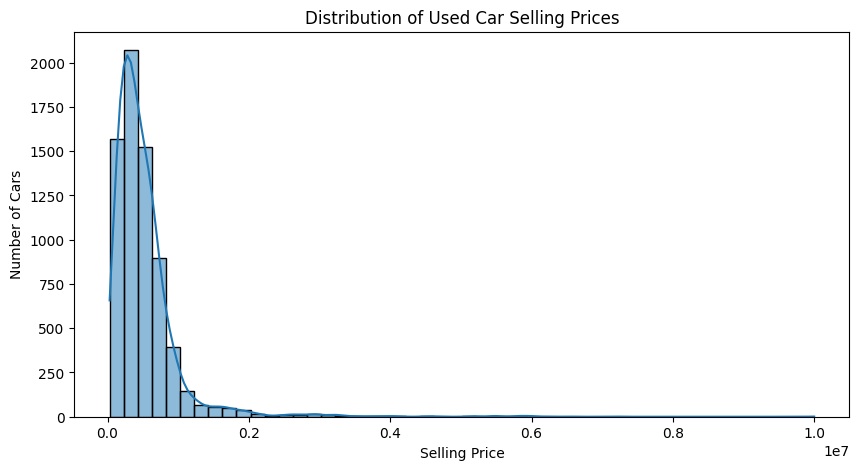

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["selling_price"],
    bins=50,
    kde=True
)

plt.title("Distribution of Used Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

In [32]:
df_clean["selling_price"].describe()

,selling_price
count,6.926000e+03
mean,5.172707e+05
std,5.197670e+05
min,2.999900e+04
25%,2.500000e+05
50%,4.000000e+05
75%,6.335000e+05
max,1.000000e+07


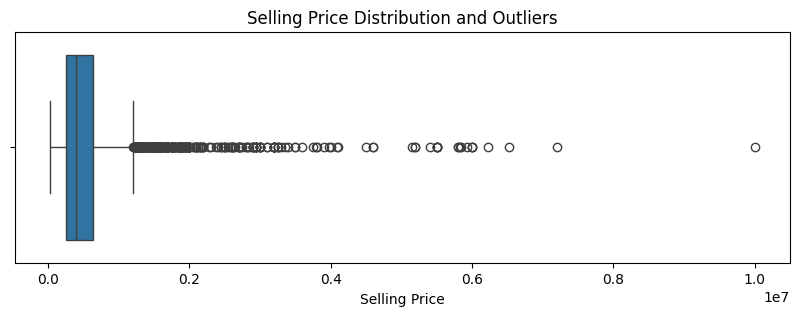

In [33]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=df_clean["selling_price"]
)

plt.title("Selling Price Distribution and Outliers")
plt.xlabel("Selling Price")
plt.show()

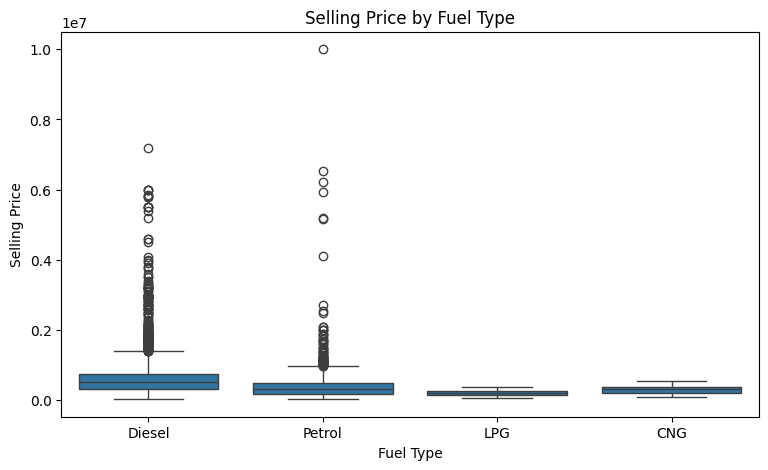

In [34]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="fuel",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

In [35]:
df_clean.groupby("fuel")["selling_price"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("median", ascending=False)

,count,mean,median,min,max
fuel,,,,,
Diesel,3755,639727.768842,520000.0,40000,7200000
CNG,56,300499.946429,320000.0,80000,545000
Petrol,3077,375688.966526,310000.0,29999,10000000
LPG,38,200421.052632,195500.0,54000,375000


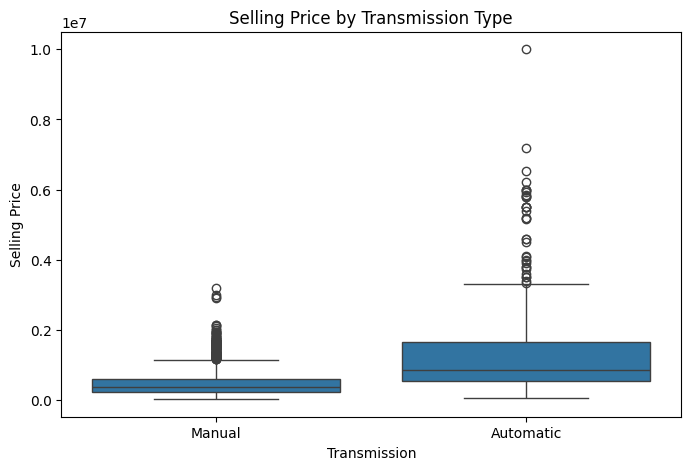

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="transmission",
    y="selling_price"
)

plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")
plt.show()

In [37]:
df_clean.groupby("transmission")["selling_price"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
transmission,,,,,
Automatic,584,1.309712e+06,850000.0,75000,10000000
Manual,6342,4.442991e+05,385000.0,29999,3200000


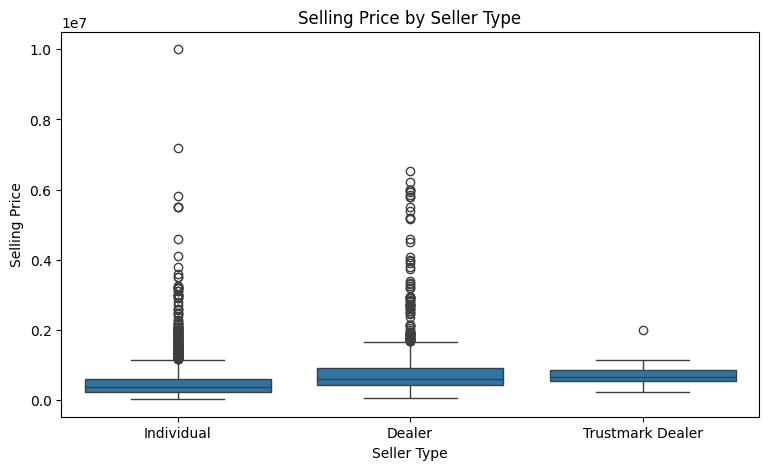

In [38]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="seller_type",
    y="selling_price"
)

plt.title("Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Selling Price")
plt.show()

In [39]:
df_clean.groupby("seller_type")["selling_price"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
seller_type,,,,,
Dealer,681,926722.415565,620000.0,60000,6523000
Individual,6218,471555.122869,390000.0,29999,10000000
Trustmark Dealer,27,718111.111111,650000.0,225000,2000000


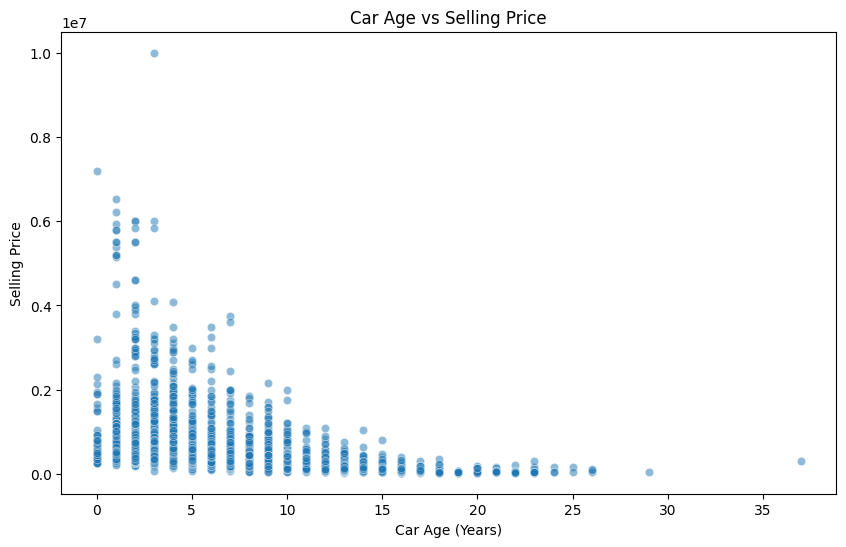

In [40]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="car_age",
    y="selling_price",
    alpha=0.5
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")
plt.show()

In [41]:
df_clean[["car_age", "selling_price"]].corr()

,car_age,selling_price
car_age,1.000000,-0.433076
selling_price,-0.433076,1.000000


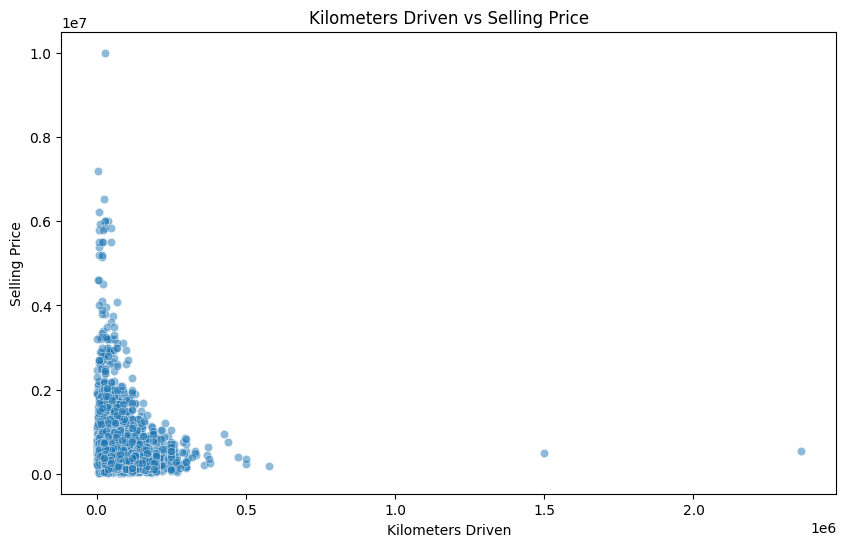

In [42]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="km_driven",
    y="selling_price",
    alpha=0.5
)

plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

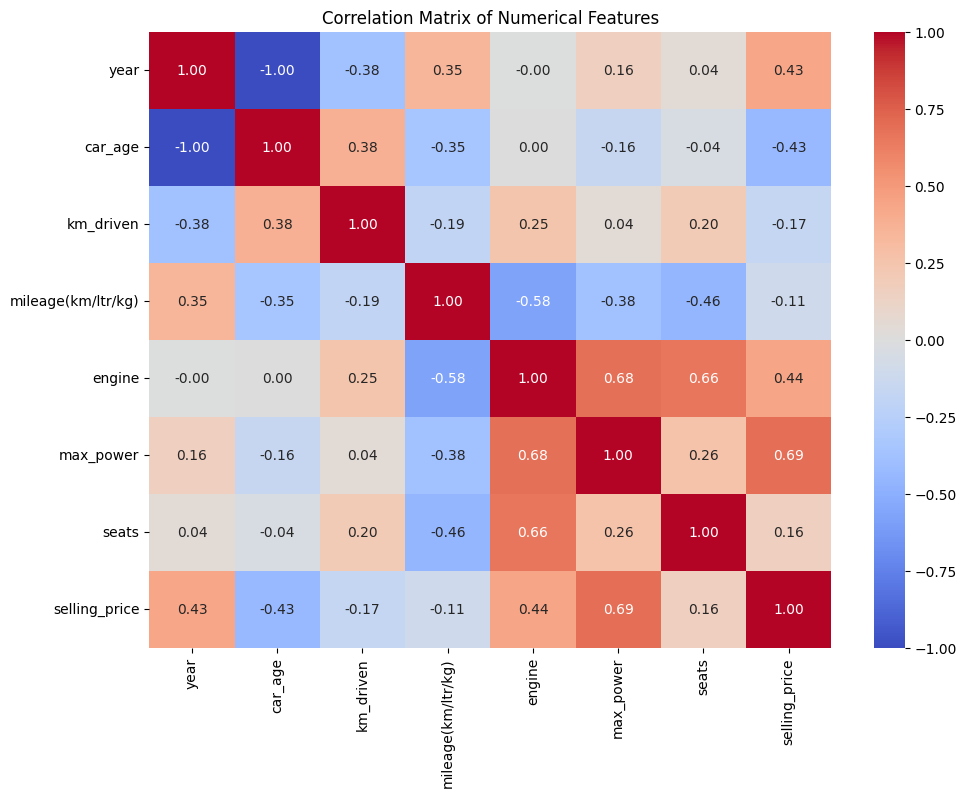

In [43]:
numeric_columns = [
    "year",
    "car_age",
    "km_driven",
    "mileage(km/ltr/kg)",
    "engine",
    "max_power",
    "seats",
    "selling_price"
]

correlation_matrix = df_clean[numeric_columns].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### EDA Observations

The exploratory analysis produced several important observations:

- Selling prices have a highly dispersed distribution with several high-value observations.
- `max_power` has the strongest positive linear correlation with selling price among the numerical features.
- `engine` and `year` also show positive relationships with selling price.
- `car_age` has a negative relationship with selling price, indicating that older vehicles generally have lower selling prices in this dataset.
- `km_driven` has a relatively weak negative correlation with selling price.
- Fuel type shows differences in selling-price distributions, with Diesel vehicles having a higher median selling price than Petrol vehicles in this dataset.
- Automatic vehicles show a different selling-price distribution from Manual vehicles.
- Seller type also shows differences in price distributions.
- Several extreme selling-price observations are visible. These observations will not be removed automatically because they may represent genuine high-value vehicles.
- `engine` and `max_power` are positively correlated, so their relationship should be considered when interpreting linear-model coefficients.

## Feature Selection

The target variable is `selling_price`.

The following features will be used for model training:

- `brand`
- `car_age`
- `km_driven`
- `fuel`
- `seller_type`
- `transmission`
- `owner`
- `mileage(km/ltr/kg)`
- `engine`
- `max_power`
- `seats`

The original `name` column will be excluded because it contains high-cardinality vehicle model names.

The original `year` column will also be excluded because `car_age` has been derived from it and provides an equivalent but more interpretable representation of vehicle age.

In [44]:
features = [
    "brand",
    "car_age",
    "km_driven",
    "fuel",
    "seller_type",
    "transmission",
    "owner",
    "mileage(km/ltr/kg)",
    "engine",
    "max_power",
    "seats"
]

target = "selling_price"

X = df_clean[features].copy()
y = df_clean[target].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (6926, 11)
Target shape: (6926,)


In [45]:
X.head()

,brand,car_age,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti,6,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda,6,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda,14,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai,10,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti,13,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


In [46]:
y.head()

,selling_price
0,450000
1,370000
2,158000
3,225000
4,130000


### Numerical and Categorical Features

Machine learning models require categorical variables to be converted into numerical representations.

The features are therefore separated into numerical and categorical groups before preprocessing.

In [47]:
categorical_features = [
    "brand",
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

numerical_features = [
    "car_age",
    "km_driven",
    "mileage(km/ltr/kg)",
    "engine",
    "max_power",
    "seats"
]

## Train/Test Split

The dataset is divided into training and testing subsets.

- 80% of the data will be used for training.
- 20% will be reserved for testing.
- `random_state=42` is used to make the experiment reproducible.

The test set will only be used for final model evaluation.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5540
Testing samples: 1386


## Categorical Encoding

Machine learning regression models require numerical input.

Categorical variables such as `brand`, `fuel`, `seller_type`, `transmission`, and `owner` will therefore be converted using One-Hot Encoding.

One-Hot Encoding creates separate binary features for each category.

`handle_unknown="ignore"` is used so that the pipeline can safely process previously unseen categories during prediction.

In [49]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", encoder, categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

## Linear Regression

Linear Regression is used as the baseline regression model.

The model attempts to learn a linear relationship between the input features and the selling price.

The preprocessing and model are combined into a single Pipeline so that the same transformations are consistently applied during training and prediction.

In [50]:
linear_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [51]:
linear_regression_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['brand', 'fuel',
                                                   'seller_type',
                                                   'transmission', 'owner']),
                                                 ('numerical', 'passthrough',
                                                  ['car_age', 'km_driven',
                                                   'mileage(km/ltr/kg)',
                                                   'engine', 'max_power',
                                                   'seats'])])),
                ('model', LinearRegression())])

### Linear Regression Predictions

The trained model is now used to predict selling prices for the unseen test dataset.

In [52]:
y_pred_lr = linear_regression_pipeline.predict(X_test)

print("Linear Regression predictions generated.")
print(y_pred_lr[:10])

Linear Regression predictions generated.
[ 625939.90828144 1036933.38892742  726763.38766543   58749.9140857
  765692.6561081   779436.44818341  303506.99661344   26167.76079716
  237836.91333516  439027.73395519]


### Linear Regression Evaluation

The model will be evaluated using three regression metrics:

- **MAE (Mean Absolute Error):** Average absolute difference between actual and predicted prices.
- **RMSE (Root Mean Squared Error):** Penalizes larger prediction errors more strongly.
- **R² (Coefficient of Determination):** Measures the proportion of variance in selling price explained by the model.

Lower MAE and RMSE indicate smaller prediction errors, while a higher R² indicates that the model explains more variance in the target.

In [53]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("Linear Regression Results")
print("-" * 30)
print(f"MAE  : {mae_lr:,.2f}")
print(f"RMSE : {rmse_lr:,.2f}")
print(f"R²   : {r2_lr:.4f}")

Linear Regression Results
------------------------------
MAE  : 133,098.53
RMSE : 261,925.34
R²   : 0.6872


In [54]:
model_results = []

model_results.append({
    "Model": "Linear Regression",
    "MAE": mae_lr,
    "RMSE": rmse_lr,
    "R2": r2_lr
})

pd.DataFrame(model_results)

,Model,MAE,RMSE,R2
0,Linear Regression,133098.533351,261925.335127,0.687195


## Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Unlike Linear Regression, Random Forest can capture non-linear relationships and interactions between features.

This model will be trained using the same preprocessing and train/test split used for Linear Regression.

In [55]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Random Forest Predictions

The trained Random Forest model is used to predict selling prices for the same unseen test dataset.

In [56]:
y_pred_rf = random_forest_pipeline.predict(X_test)

print("Predictions generated successfully.")
print("\nFirst 10 predictions:")
print(y_pred_rf[:10])

Predictions generated successfully.

First 10 predictions:
[ 699303.31666667 1054747.04055556  849784.43777778  141244.92
  698293.33333333  931383.9331746   305161.83333333  235776.59333333
  230093.87555556  523566.64666667]


### Random Forest Evaluation

The Random Forest model is evaluated using the same metrics as Linear Regression:

- MAE
- RMSE
- R²

Using the same test set allows a fair comparison between the two models.

In [57]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Results")
print("-" * 35)
print(f"MAE  : {mae_rf:,.2f}")
print(f"RMSE : {rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Results
-----------------------------------
MAE  : 72,813.50
RMSE : 127,099.92
R²   : 0.9263


## Model Comparison

Two regression models were trained and evaluated on the same held-out test dataset.

The models are compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

This comparison helps identify how differently the models perform on the same prediction task.

In [58]:
model_results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mae_lr,
        "RMSE": rmse_lr,
        "R2": r2_lr
    },
    {
        "Model": "Random Forest",
        "MAE": mae_rf,
        "RMSE": rmse_rf,
        "R2": r2_rf
    }
])

model_results

,Model,MAE,RMSE,R2
0,Linear Regression,133098.533351,261925.335127,0.687195
1,Random Forest,72813.495294,127099.920694,0.926344


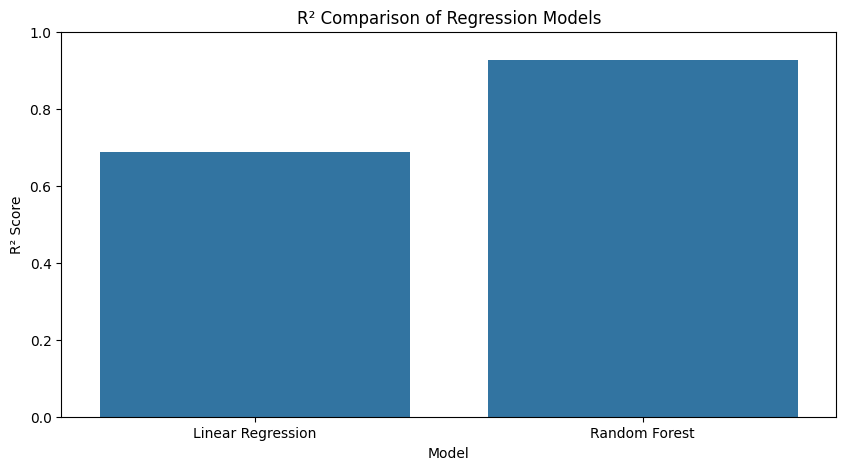

In [59]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=model_results,
    x="Model",
    y="R2"
)

plt.title("R² Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.show()

### Model Comparison Observations

The two regression models produced different results on the held-out test set.

Linear Regression achieved:

- MAE: ₹133,098.53
- RMSE: ₹261,925.34
- R²: 0.6872

Random Forest achieved:

- MAE: ₹72,813.50
- RMSE: ₹127,099.92
- R²: 0.9263

The Random Forest model produced substantially lower MAE and RMSE and a higher R² score on the test dataset.

This indicates that the Random Forest model was able to capture nonlinear relationships between vehicle characteristics and selling price more effectively than the Linear Regression baseline.

## Actual vs Predicted Prices

This analysis compares the actual selling prices from the test dataset with the prices predicted by the trained models.

A model with accurate predictions should produce points close to the diagonal reference line.

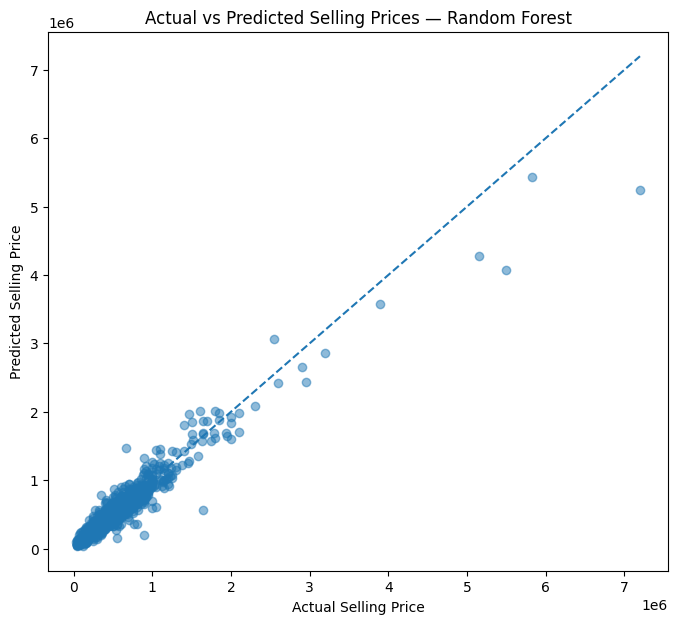

In [60]:
plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

min_price = min(y_test.min(), y_pred_rf.min())
max_price = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.title("Actual vs Predicted Selling Prices — Random Forest")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.show()

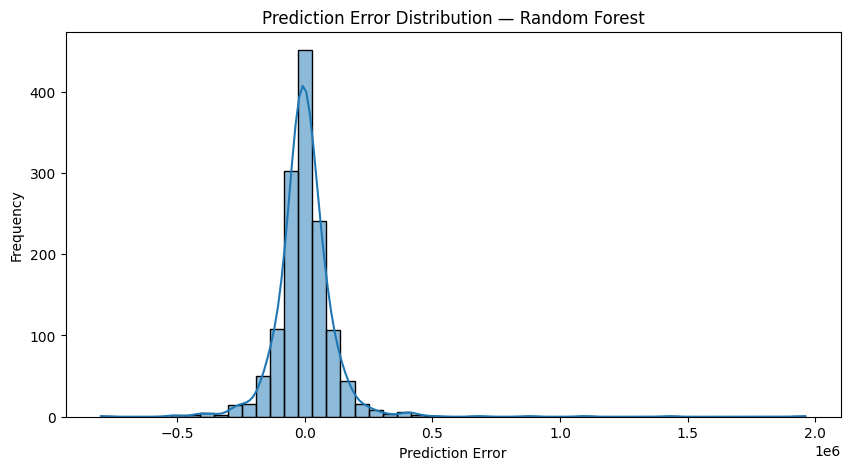

In [61]:
errors_rf = y_test - y_pred_rf

plt.figure(figsize=(10, 5))

sns.histplot(
    errors_rf,
    bins=50,
    kde=True
)

plt.title("Prediction Error Distribution — Random Forest")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [62]:
print("Random Forest Error Statistics")
print("-" * 35)

print(f"Mean Error   : {errors_rf.mean():,.2f}")
print(f"Median Error : {np.median(errors_rf):,.2f}")
print(f"Minimum Error: {errors_rf.min():,.2f}")
print(f"Maximum Error: {errors_rf.max():,.2f}")

Random Forest Error Statistics
-----------------------------------
Mean Error   : 476.83
Median Error : -5,403.89
Minimum Error: -799,156.66
Maximum Error: 1,960,976.67


## Feature Importance

Feature importance is used to understand which input variables contributed most to the Random Forest model's predictions.

Because categorical variables were transformed using One-Hot Encoding, the original categorical features are expanded into multiple encoded features.

The feature importance values will therefore be mapped back to the transformed feature names.

In [63]:
rf_preprocessor = random_forest_pipeline.named_steps["preprocessor"]
rf_model = random_forest_pipeline.named_steps["model"]

encoded_feature_names = (
    rf_preprocessor
    .named_transformers_["categorical"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = np.concatenate([
    encoded_feature_names,
    numerical_features
])

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    "Importance",
    ascending=False
)

feature_importance_df.head(20)

,Feature,Importance
48,max_power,0.600193
44,car_age,0.228332
45,km_driven,0.048562
46,mileage(km/ltr/kg),0.037411
47,engine,0.023438
49,seats,0.009677
19,brand_Mercedes-Benz,0.006044
27,brand_Toyota,0.005622
26,brand_Tata,0.004056
15,brand_Land,0.004010


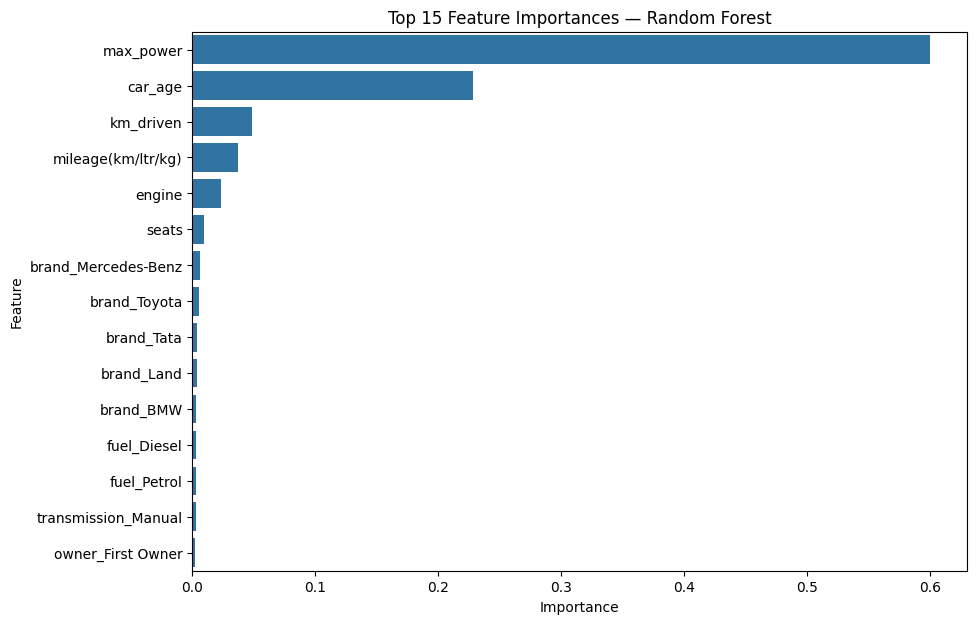

In [64]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Error Analysis

Error analysis is used to understand where the Random Forest model makes larger prediction errors.

The prediction error is calculated as:

Actual Selling Price − Predicted Selling Price

The analysis will examine:

- Absolute prediction error
- Largest prediction errors
- Actual versus predicted prices
- Whether extreme prices contribute to larger errors

In [65]:
error_analysis = pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": y_pred_rf
})

error_analysis["Error"] = (
    error_analysis["Actual_Price"]
    - error_analysis["Predicted_Price"]
)

error_analysis["Absolute_Error"] = (
    error_analysis["Error"].abs()
)

error_analysis["Percentage_Error"] = (
    error_analysis["Absolute_Error"]
    / error_analysis["Actual_Price"].replace(0, np.nan)
) * 100

error_analysis.head()

,Actual_Price,Predicted_Price,Error,Absolute_Error,Percentage_Error
0,550000,6.993033e+05,-149303.316667,149303.316667,27.146058
1,1225000,1.054747e+06,170252.959444,170252.959444,13.898201
2,850000,8.497844e+05,215.562222,215.562222,0.025360
3,80000,1.412449e+05,-61244.920000,61244.920000,76.556150
4,825000,6.982933e+05,126706.666667,126706.666667,15.358384


In [66]:
largest_errors = error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
)

largest_errors.head(10)

,Actual_Price,Predicted_Price,Error,Absolute_Error,Percentage_Error
571,7200000,5.239023e+06,1.960977e+06,1.960977e+06,27.235787
468,5500000,4.077553e+06,1.422447e+06,1.422447e+06,25.862667
704,1650000,5.566800e+05,1.093320e+06,1.093320e+06,66.261819
112,5150000,4.280240e+06,8.697600e+05,8.697600e+05,16.888544
1364,667000,1.466157e+06,-7.991567e+05,7.991567e+05,119.813593
525,890000,2.045048e+05,6.854952e+05,6.854952e+05,77.021938
429,2550000,3.066480e+06,-5.164799e+05,5.164799e+05,20.254115
1358,2950000,2.440933e+06,5.090675e+05,5.090675e+05,17.256525
1115,1465000,1.973023e+06,-5.080233e+05,5.080233e+05,34.677359
610,800000,3.596733e+05,4.403267e+05,4.403267e+05,55.040842


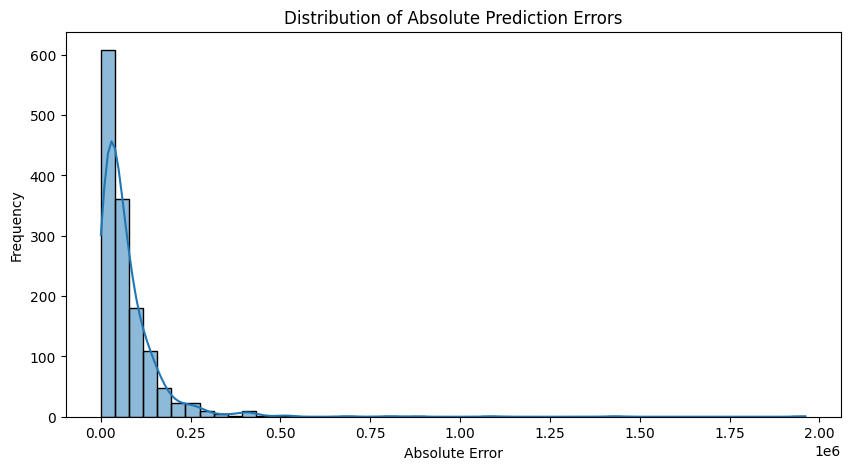

In [67]:
plt.figure(figsize=(10, 5))

sns.histplot(
    error_analysis["Absolute_Error"],
    bins=50,
    kde=True
)

plt.title("Distribution of Absolute Prediction Errors")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")

plt.show()

In [68]:
mape_rf = (
    np.mean(
        np.abs(
            (y_test.values - y_pred_rf)
            / np.where(y_test.values == 0, np.nan, y_test.values)
        )
    ) * 100
)

print(f"MAPE: {mape_rf:.2f}%")

MAPE: 18.03%


## New Car Price Prediction

The trained Random Forest pipeline can be used to estimate the selling price of a new vehicle based on its characteristics.

The input must contain the same features used during model training.


In [69]:
new_car = pd.DataFrame({
    "brand": ["Maruti"],
    "car_age": [5],
    "km_driven": [50000],
    "fuel": ["Petrol"],
    "seller_type": ["Individual"],
    "transmission": ["Manual"],
    "owner": ["First Owner"],
    "mileage(km/ltr/kg)": [20.0],
    "engine": [1197.0],
    "max_power": [82.0],
    "seats": [5.0]
})

new_car

,brand,car_age,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti,5,50000,Petrol,Individual,Manual,First Owner,20.0,1197.0,82.0,5.0


In [70]:
predicted_price = random_forest_pipeline.predict(new_car)[0]

print(
    f"Estimated Selling Price: ₹{predicted_price:,.2f}"
)

Estimated Selling Price: ₹418,077.41


## Final Results

The project evaluated two regression models for used-car price prediction.

### Model Performance

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | ₹133,098.53 | ₹261,925.34 | 0.6872 |
| Random Forest | ₹72,813.50 | ₹127,099.92 | 0.9263 |

The Random Forest model achieved lower MAE and RMSE and a higher R² score on the held-out test dataset.

The final model demonstrates that vehicle characteristics such as power, engine capacity, vehicle age, mileage, brand, and other categorical attributes contain useful information for estimating used-car selling prices.

## Conclusion

This project developed an end-to-end machine learning regression pipeline for used-car price prediction.

The workflow included:

1. Dataset collection
2. Dataset understanding
3. Data cleaning
4. Duplicate removal
5. Missing-value handling
6. Feature engineering
7. Exploratory data analysis
8. Feature selection
9. Categorical encoding
10. Train/test splitting
11. Linear Regression
12. Random Forest Regression
13. Model evaluation
14. Feature importance analysis
15. Error analysis
16. New vehicle price prediction

Two regression models were evaluated using MAE, RMSE, and R².

The Random Forest model achieved an R² score of 0.9263 on the held-out test dataset, while Linear Regression achieved an R² score of 0.6872.

The results demonstrate the usefulness of machine learning for modelling relationships between vehicle characteristics and used-car selling prices.

## Limitations

- The dataset represents a particular collection of used-car listings and may not represent every used-car market.
- The data is limited to vehicles represented in the dataset's time period.
- Some numerical values were missing and were imputed using median values.
- Extreme selling-price observations are present in the dataset.
- The model does not include every factor that can influence a vehicle's market value.
- Actual market prices can change over time due to location, demand, vehicle condition, and market conditions.
- Model performance on future data may differ from the performance measured on this test set.

## Future Improvements

Potential improvements include:

- Incorporating vehicle location and regional market information
- Using more detailed vehicle-model features
- Including vehicle condition and service history
- Testing Gradient Boosting and other advanced regression algorithms
- Performing systematic hyperparameter tuning
- Applying cross-validation
- Investigating appropriate treatment of extreme price observations
- Building a web-based prediction interface using FastAPI or Streamlit
- Saving the trained preprocessing and model pipeline for deployment
- Monitoring model performance on new market data

## Final Architecture

```text
Kaggle Car Dataset
        │
        ▼
Dataset Loading
        │
        ▼
Dataset Understanding
        │
        ▼
Data Cleaning
 ├── Duplicate Removal
 ├── Missing Value Handling
 └── Data Type Conversion
        │
        ▼
Feature Engineering
 ├── Brand Extraction
 └── Car Age Creation
        │
        ▼
Exploratory Data Analysis
        │
        ▼
Feature Selection
        │
        ▼
Train / Test Split
        │
        ▼
Preprocessing
 └── One-Hot Encoding
        │
        ├───────────────┐
        ▼               ▼
Linear Regression   Random Forest
        │               │
        └───────┬───────┘
                ▼
         Model Evaluation
       ├── MAE
       ├── RMSE
       └── R²
                │
                ▼
         Feature Importance
                │
                ▼
          Error Analysis
                │
                ▼
      New Car Price Prediction


## Final notebook order

You should now have the complete professional flow:

```text
1.  Project Title
2.  Problem Statement
3.  Objectives
4.  What Are We Building?
5.  Technologies
6.  Import Libraries
7.  Dataset Collection
8.  Load Dataset
9.  Dataset Understanding
10. Data Cleaning
11. Feature Engineering
12. Exploratory Data Analysis
13. Feature Selection
14. Train/Test Split
15. Categorical Encoding & Preprocessing
16. Linear Regression
17. Random Forest Regressor
18. Model Comparison
19. Actual vs Predicted Prices
20. Feature Importance
21. Error Analysis
22. New Car Price Prediction
23. Final Results
24. Conclusion
25. Limitations
26. Future Improvements
27. Final Architecture

## Sample Testing

The trained Random Forest model is tested using multiple sample vehicle inputs.

These examples demonstrate how the model responds to different combinations of:

- Brand
- Car age
- Kilometers driven
- Fuel type
- Seller type
- Transmission
- Ownership history
- Mileage
- Engine capacity
- Maximum power
- Seating capacity

The predictions are model estimates and are not actual market quotations.

In [71]:
sample_cars = pd.DataFrame({
    "brand": [
        "Maruti",
        "Hyundai",
        "Toyota",
        "Honda",
        "BMW"
    ],
    "car_age": [
        3,
        5,
        4,
        7,
        2
    ],
    "km_driven": [
        30000,
        50000,
        40000,
        70000,
        25000
    ],
    "fuel": [
        "Petrol",
        "Diesel",
        "Diesel",
        "Petrol",
        "Diesel"
    ],
    "seller_type": [
        "Individual",
        "Individual",
        "Dealer",
        "Individual",
        "Dealer"
    ],
    "transmission": [
        "Manual",
        "Manual",
        "Automatic",
        "Manual",
        "Automatic"
    ],
    "owner": [
        "First Owner",
        "First Owner",
        "First Owner",
        "Second Owner",
        "First Owner"
    ],
    "mileage(km/ltr/kg)": [
        20.0,
        22.0,
        18.0,
        17.0,
        18.0
    ],
    "engine": [
        1197.0,
        1396.0,
        1496.0,
        1497.0,
        1995.0
    ],
    "max_power": [
        82.0,
        90.0,
        108.0,
        118.0,
        190.0
    ],
    "seats": [
        5.0,
        5.0,
        5.0,
        5.0,
        5.0
    ]
})

sample_cars

,brand,car_age,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti,3,30000,Petrol,Individual,Manual,First Owner,20.0,1197.0,82.0,5.0
1,Hyundai,5,50000,Diesel,Individual,Manual,First Owner,22.0,1396.0,90.0,5.0
2,Toyota,4,40000,Diesel,Dealer,Automatic,First Owner,18.0,1496.0,108.0,5.0
3,Honda,7,70000,Petrol,Individual,Manual,Second Owner,17.0,1497.0,118.0,5.0
4,BMW,2,25000,Diesel,Dealer,Automatic,First Owner,18.0,1995.0,190.0,5.0


In [72]:
sample_predictions = random_forest_pipeline.predict(sample_cars)

sample_results = sample_cars.copy()

sample_results["Predicted_Selling_Price"] = sample_predictions

sample_results["Predicted_Selling_Price"] = (
    sample_results["Predicted_Selling_Price"]
    .round(2)
)

sample_results[
    [
        "brand",
        "car_age",
        "km_driven",
        "fuel",
        "transmission",
        "Predicted_Selling_Price"
    ]
]


,brand,car_age,km_driven,fuel,transmission,Predicted_Selling_Price
0,Maruti,3,30000,Petrol,Manual,537973.27
1,Hyundai,5,50000,Diesel,Manual,659803.06
2,Toyota,4,40000,Diesel,Automatic,870287.22
3,Honda,7,70000,Petrol,Manual,483293.33
4,BMW,2,25000,Diesel,Automatic,3807400.00


In [73]:
display_results = sample_results[
    [
        "brand",
        "car_age",
        "km_driven",
        "fuel",
        "transmission",
        "Predicted_Selling_Price"
    ]
].copy()

display_results["Predicted_Selling_Price"] = (
    display_results["Predicted_Selling_Price"]
    .map(lambda x: f"₹{x:,.0f}")
)

display_results

,brand,car_age,km_driven,fuel,transmission,Predicted_Selling_Price
0,Maruti,3,30000,Petrol,Manual,"₹537,973"
1,Hyundai,5,50000,Diesel,Manual,"₹659,803"
2,Toyota,4,40000,Diesel,Automatic,"₹870,287"
3,Honda,7,70000,Petrol,Manual,"₹483,293"
4,BMW,2,25000,Diesel,Automatic,"₹3,807,400"


In [74]:
custom_car = pd.DataFrame({
    "brand": ["Maruti"],
    "car_age": [5],
    "km_driven": [50000],
    "fuel": ["Petrol"],
    "seller_type": ["Individual"],
    "transmission": ["Manual"],
    "owner": ["First Owner"],
    "mileage(km/ltr/kg)": [20.0],
    "engine": [1197.0],
    "max_power": [82.0],
    "seats": [5.0]
})

custom_prediction = random_forest_pipeline.predict(custom_car)[0]

print(f"Estimated Selling Price: ₹{custom_prediction:,.0f}")

Estimated Selling Price: ₹418,077


### Sample Prediction Result

The trained Random Forest pipeline successfully accepts a new vehicle's characteristics and produces an estimated selling price.

This demonstrates the complete prediction workflow from structured vehicle input to machine learning output.

In [75]:
comparison_cars = pd.DataFrame({
    "brand": ["Maruti", "Maruti"],
    "car_age": [2, 12],
    "km_driven": [30000, 120000],
    "fuel": ["Petrol", "Petrol"],
    "seller_type": ["Individual", "Individual"],
    "transmission": ["Manual", "Manual"],
    "owner": ["First Owner", "Third Owner"],
    "mileage(km/ltr/kg)": [20.0, 17.0],
    "engine": [1197.0, 1197.0],
    "max_power": [82.0, 82.0],
    "seats": [5.0, 5.0]
})

comparison_predictions = random_forest_pipeline.predict(
    comparison_cars
)

comparison_results = comparison_cars[
    ["brand", "car_age", "km_driven", "owner"]
].copy()

comparison_results["Predicted_Price"] = comparison_predictions

comparison_results["Predicted_Price"] = (
    comparison_results["Predicted_Price"]
    .map(lambda x: f"₹{x:,.0f}")
)

comparison_results

,brand,car_age,km_driven,owner,Predicted_Price
0,Maruti,2,30000,First Owner,"₹532,102"
1,Maruti,12,120000,Third Owner,"₹183,648"
